# Unemployment Analysis with Python

This notebook is created for Task 2 of the Oasis Infobyte Data Science Internship. The aim is to analyze unemployment trends in India and understand the impact of COVID-19 on unemployment.

## 1. Import Libraries

In this step, we import the Python libraries required for data analysis and visualization.

- `pandas` is used to load and manage the dataset.
- `numpy` is used for numerical operations.
- `matplotlib` and `seaborn` are used to create charts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load Dataset

Here, we load the unemployment dataset using `pd.read_csv()`. The dataset is stored in the same folder as this notebook, so we can use the file name directly.

In [2]:
df = pd.read_csv("Unemployment.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. Dataset Overview

Before analysis, we check the number of rows and columns, column names, and basic dataset information.

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

## 4. Data Cleaning

Some column names have extra spaces. We remove those spaces so the column names are easier to use. We also rename `Region.1` to `Zone` because it represents the geographical zone.

In [3]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Rename Region.1 to Zone for better understanding
df = df.rename(columns={"Region.1": "Zone"})

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Zone',
       'longitude', 'latitude'],
      dtype='object')

The `Date` column is currently stored as text. We convert it into proper date format so monthly trend analysis becomes easier.

In [4]:
# Convert Date column into datetime format
df["Date"] = pd.to_datetime(df["Date"].str.strip(), format="%d-%m-%Y")

# Create a Month column for easier plotting
df["Month"] = df["Date"].dt.strftime("%b")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Zone,longitude,latitude,Month
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,Jan
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,Feb
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,Mar
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,Apr
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,May


## 5. Missing Values and Duplicate Records

Missing values can affect analysis results. Duplicate rows can repeat the same information and may give incorrect results.

In [5]:
# Check missing values in each column
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Zone                                       0
longitude                                  0
latitude                                   0
Month                                      0
dtype: int64

In [6]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

## 6. Statistical Summary

The `describe()` function gives a quick summary of numerical columns such as mean, minimum, maximum, and standard deviation.

In [7]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


## 7. Outlier Check

A boxplot helps us check whether unemployment rate has unusually high or low values. These values are not always wrong, but they should be noticed during analysis.

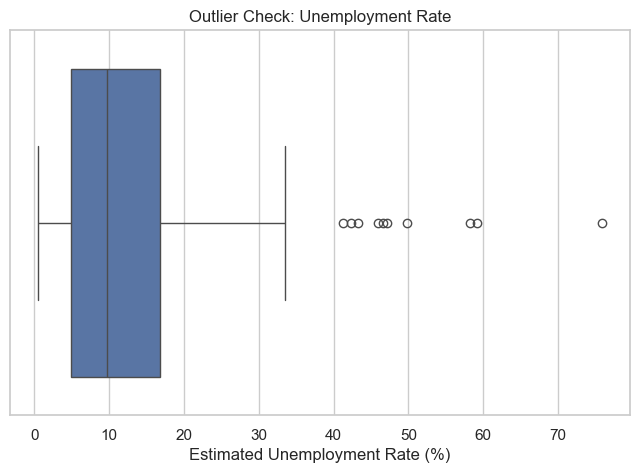

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Estimated Unemployment Rate (%)"])
plt.title("Outlier Check: Unemployment Rate")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.show()

## 8. Dataset Overview Visualization

This chart shows how many records are available for each zone in the dataset.

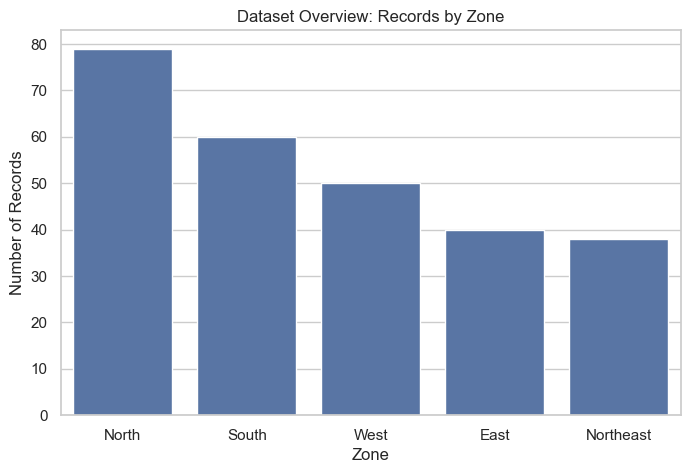

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Zone", order=df["Zone"].value_counts().index)
plt.title("Dataset Overview: Records by Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Records")
plt.show()

## 9. Missing Values Visualization

This chart shows missing values column-wise. If all bars are zero, it means the dataset does not have missing values.

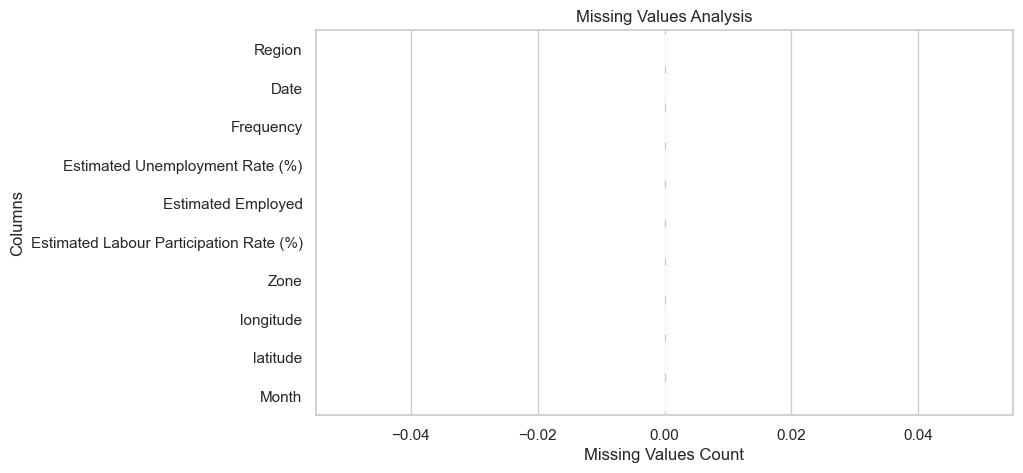

In [10]:
missing_values = df.isnull().sum()

plt.figure(figsize=(9, 5))
sns.barplot(x=missing_values.values, y=missing_values.index)
plt.title("Missing Values Analysis")
plt.xlabel("Missing Values Count")
plt.ylabel("Columns")
plt.show()

## 10. Unemployment Rate Distribution

This histogram shows how unemployment rates are distributed. It helps us understand whether most values are low, medium, or high.

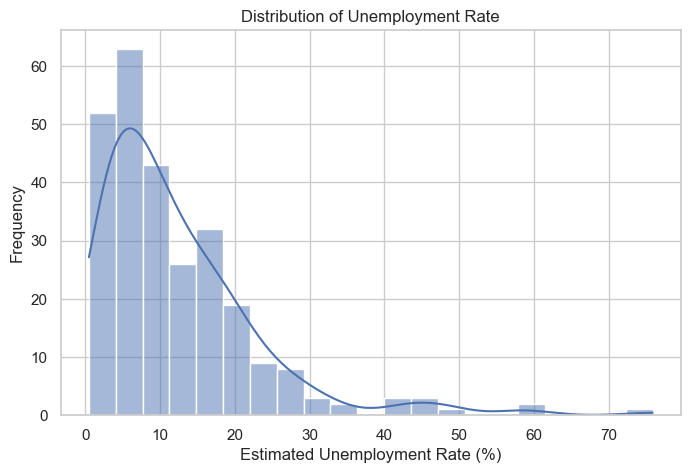

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Estimated Unemployment Rate (%)"], kde=True)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

## 11. State-wise Unemployment Rate

Here, we calculate the average unemployment rate for each state and plot it using a bar chart.

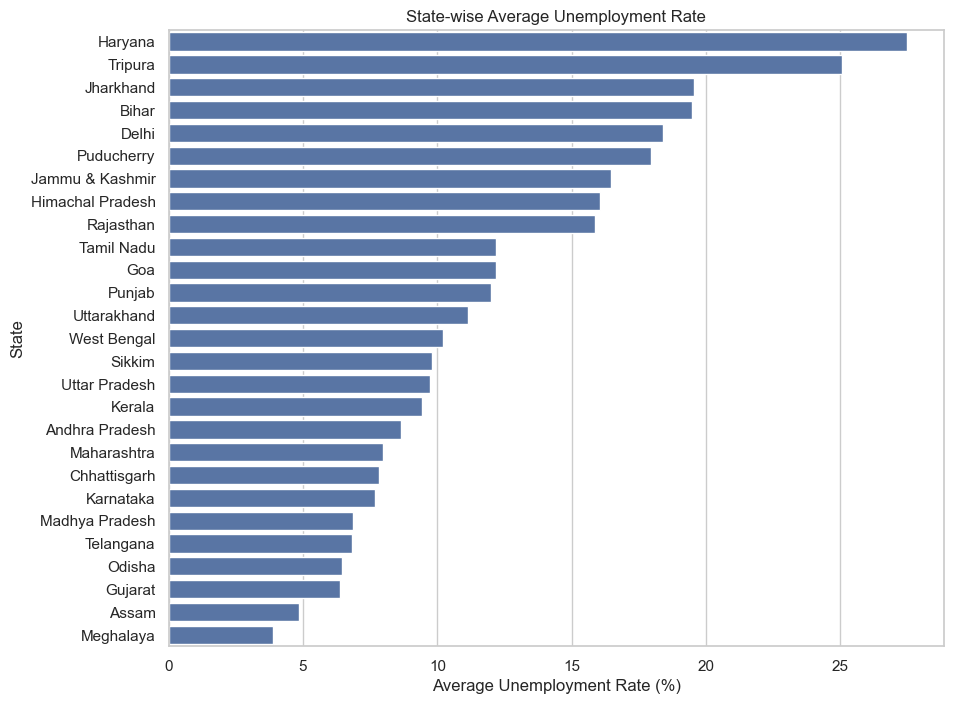

In [12]:
state_unemployment = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=state_unemployment.values, y=state_unemployment.index)
plt.title("State-wise Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

## 12. Monthly Unemployment Trend

This line chart shows how the average unemployment rate changed month by month in 2020.

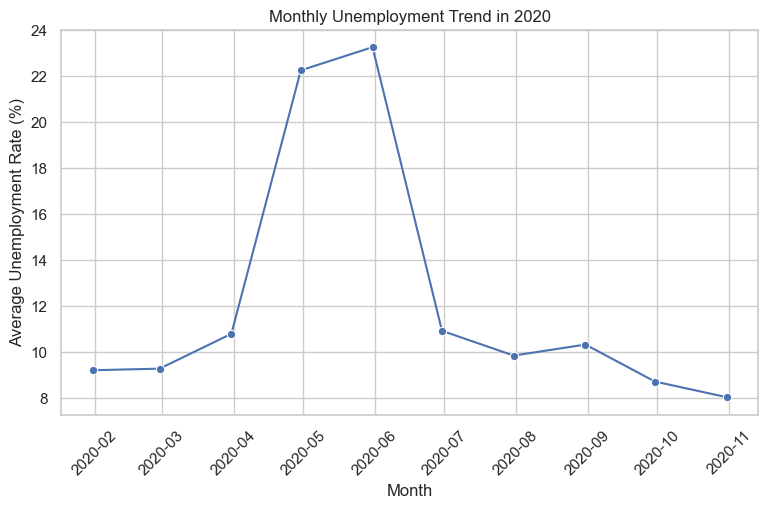

In [13]:
monthly_trend = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.lineplot(data=monthly_trend, x="Date", y="Estimated Unemployment Rate (%)", marker="o")
plt.title("Monthly Unemployment Trend in 2020")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

## 13. COVID-19 Impact Analysis

To study COVID-19 impact, we divide the data into three periods:

- Before Lockdown: January to March 2020
- Lockdown Impact: April and May 2020
- After Lockdown: June to October 2020

In [14]:
def covid_period(date):
    if date < pd.Timestamp("2020-04-01"):
        return "Before Lockdown"
    elif date <= pd.Timestamp("2020-05-31"):
        return "Lockdown Impact"
    else:
        return "After Lockdown"

df["COVID_Period"] = df["Date"].apply(covid_period)

covid_impact = df.groupby("COVID_Period")["Estimated Unemployment Rate (%)"].mean()
covid_impact = covid_impact.reindex(["Before Lockdown", "Lockdown Impact", "After Lockdown"])

covid_impact

COVID_Period
Before Lockdown     9.761519
Lockdown Impact    22.749811
After Lockdown      9.558222
Name: Estimated Unemployment Rate (%), dtype: float64

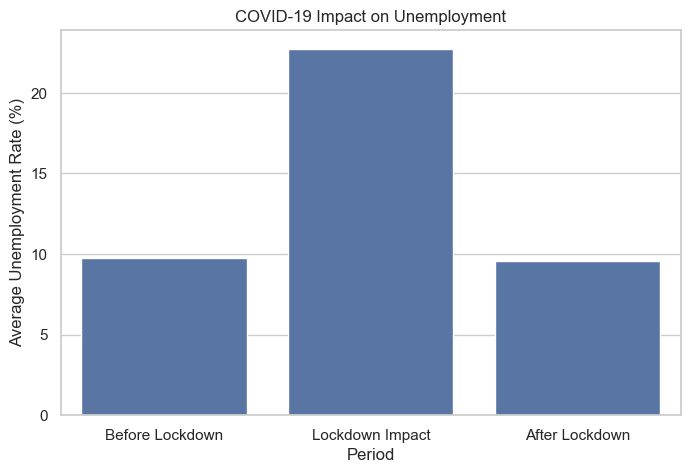

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(x=covid_impact.index, y=covid_impact.values)
plt.title("COVID-19 Impact on Unemployment")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

## 14. Correlation Heatmap

A correlation heatmap shows how numerical columns are related to each other. Values near 1 mean strong positive relation, values near -1 mean strong negative relation, and values near 0 mean weak relation.

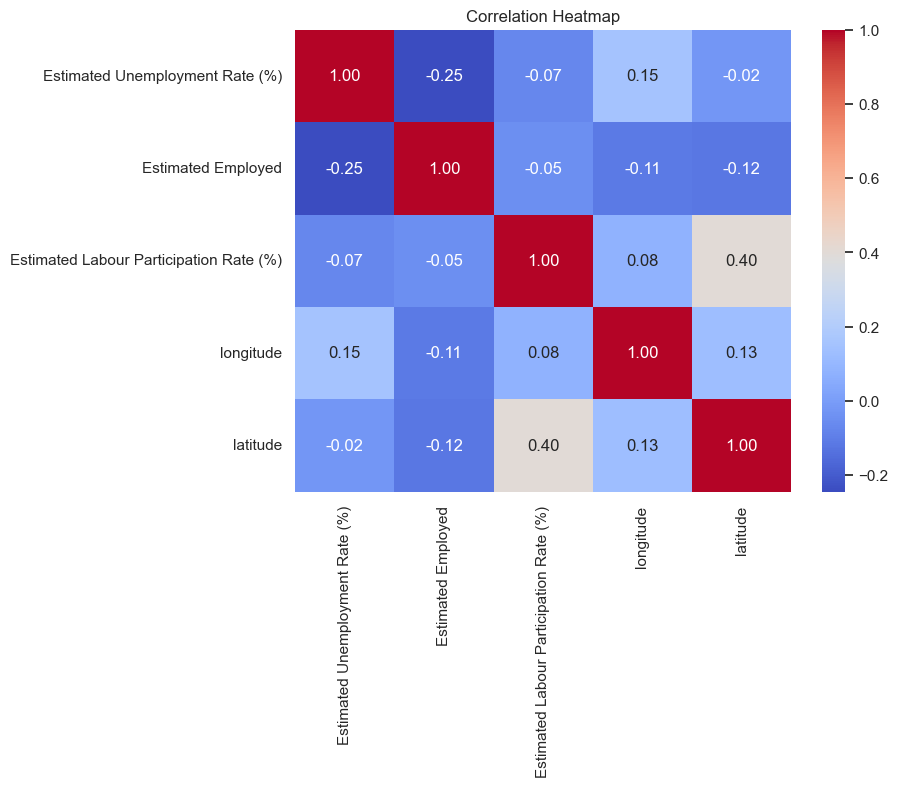

In [16]:
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
    "longitude",
    "latitude"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 15. Top 10 States with Highest Unemployment

This chart shows the states with the highest average unemployment rates.

In [ ]:
top_10_highest = state_unemployment.head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_10_highest.values, y=top_10_highest.index)
plt.title("Top 10 States with Highest Average Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

## 16. Top 10 States with Lowest Unemployment

This chart shows the states with the lowest average unemployment rates.

In [ ]:
top_10_lowest = state_unemployment.sort_values().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_10_lowest.values, y=top_10_lowest.index)
plt.title("Top 10 States with Lowest Average Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

## 17. Additional Insight: Zone-wise Unemployment

This chart compares the average unemployment rate across different zones of India.

In [ ]:
zone_unemployment = df.groupby("Zone")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=zone_unemployment.index, y=zone_unemployment.values)
plt.title("Zone-wise Average Unemployment Rate")
plt.xlabel("Zone")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

## 18. Key Findings

- The dataset contains state-wise unemployment data for 2020.
- There are no missing values in the main dataset.
- April and May 2020 show a sharp increase in unemployment.
- The lockdown impact period had a much higher unemployment rate than the before-lockdown period.
- Haryana, Tripura, Jharkhand, Bihar, and Delhi had high average unemployment rates.
- Meghalaya, Assam, Gujarat, Odisha, and Telangana had low average unemployment rates.

## 19. Conclusion

This project shows that unemployment increased sharply during the COVID-19 lockdown months. The analysis also shows that unemployment was not equal across all states. Some states had very high unemployment rates, while others had comparatively lower rates.